In [1]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from langchain.messages import RemoveMessage

from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
llm = ChatOpenAI(model = "gpt-4o-mini")

In [4]:
def chat(state: MessagesState):
    response = llm.invoke(state['messages'])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state['messages']

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(m.id) for m in to_remove]}
    
    return {}

In [5]:
builder = StateGraph(MessagesState)

builder.add_node("chat_node", chat)
builder.add_node("cleanup", delete_old_messages)

builder.add_edge(START, "chat_node")
builder.add_edge("chat_node", "cleanup")
builder.add_edge("cleanup", END)

In [6]:
graph = builder.compile(checkpointer = InMemorySaver())

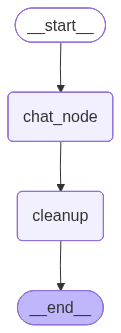

In [7]:
graph

In [8]:
config = {"configurable": {"thread_id": "t1"}}

In [9]:
# Run multiple turns
graph.invoke({"messages": [HumanMessage(content = "Hi, I am Rahul!")]}, config)
graph.invoke({"messages": [HumanMessage(content = "Tell me about LangGraph")]}, config)
graph.invoke({"messages": [HumanMessage(content = "Now explain checkpointers")]}, config)
graph.invoke({"messages": [HumanMessage(content = "What is Langchain")]}, config)
graph.invoke({"messages": [HumanMessage(content = "What is Quantum Mechanics")]}, config)
graph.invoke({"messages": [HumanMessage(content = "What is Gen AI")]}, config)
graph.invoke({"messages": [HumanMessage(content = "What is my name?")]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='c79ab3f1-0ae3-487c-bc82-d0aeede1aa6d'),
  AIMessage(content='LangChain is an open-source framework designed to simplify the development of applications that utilize large language models (LLMs). It provides a set of tools, components, and abstractions that allow developers to create complex and interactive applications by integrating language models with various data sources, APIs, and workflows.\n\n### Key Features of LangChain:\n\n1. **Modular Components**: LangChain offers modular building blocks for various functionalities, such as prompt creation, input/output handling, memory management, agent execution, and more. This modularity allows developers to easily customize and extend their applications.\n\n2. **Prompt Management**: The framework helps in effectively managing prompts, which are crucial for interacting with language models. It provides utilities for constructing, stori

In [11]:
snap = graph.get_state(config)
print("Total stored messages after cleanup:", len(snap.values.get("messages", [])))

Total stored messages after cleanup: 8


In [ ]:
# But trimming/deleletion mein bhi ek flaw hai ki hum poora hi hata de rahe hain past messages ko but kuch case mein earlier messages bhi important hote hain.
# So before deleting them, summarizing those messages is a better option.
# So in the next notebook, we are going to implement summarization.